   Age  Gender Country Academic_Level Most_Used_Platform Purpose_Of_Use  \
0   21    Male   Other  Undergraduate           Facebook     Networking   
1   23  Female   Other       Graduate           LinkedIn      Education   
2   22    Male  Canada  Undergraduate          Instagram  Entertainment   
3   18    Male   Other    High School           Snapchat  Entertainment   
4   24  Female   Other       Graduate           Facebook     Networking   

   Avg_Daily_Usage_Hours  Daily_Unlocks  Study_Hours  Physical_Activity_Hours  \
0                    4.0            134          4.5                      2.2   
1                    1.6             73          7.0                      2.4   
2                    4.6            166          4.0                      1.8   
3                    7.0            220          1.0                      1.7   
4                    7.5            237          1.0                      1.1   

   Sleep_Hours_Per_Night Stress_Level  Mental_Health_Score  
0

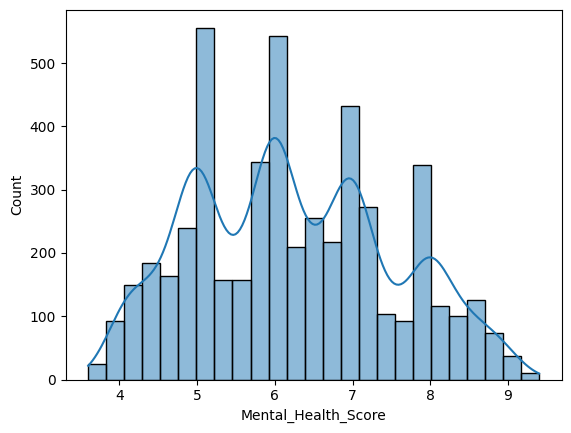

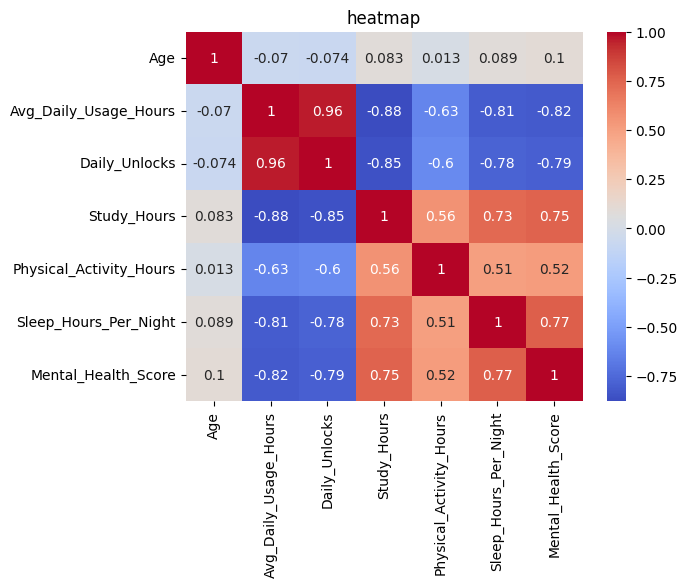

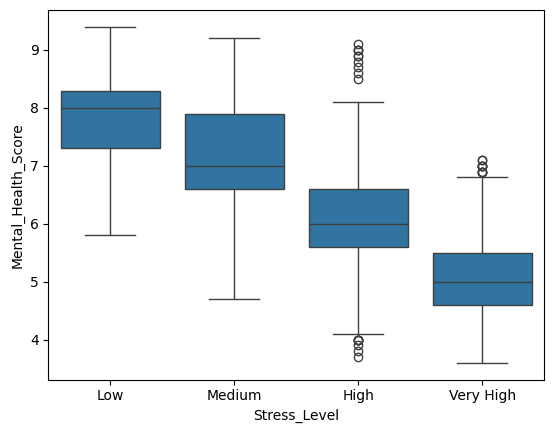

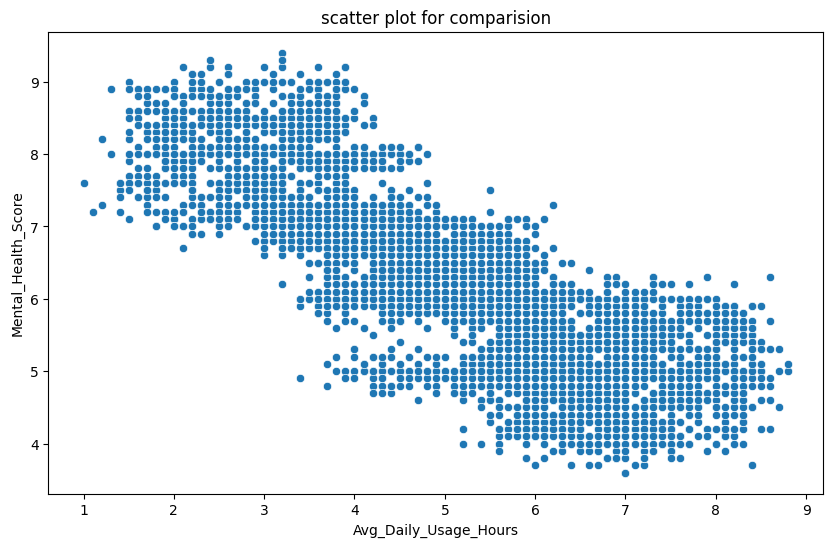

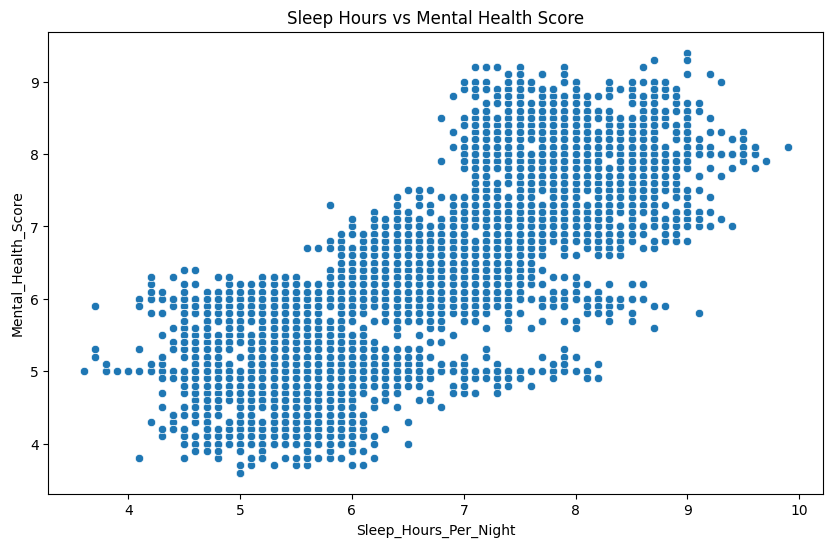

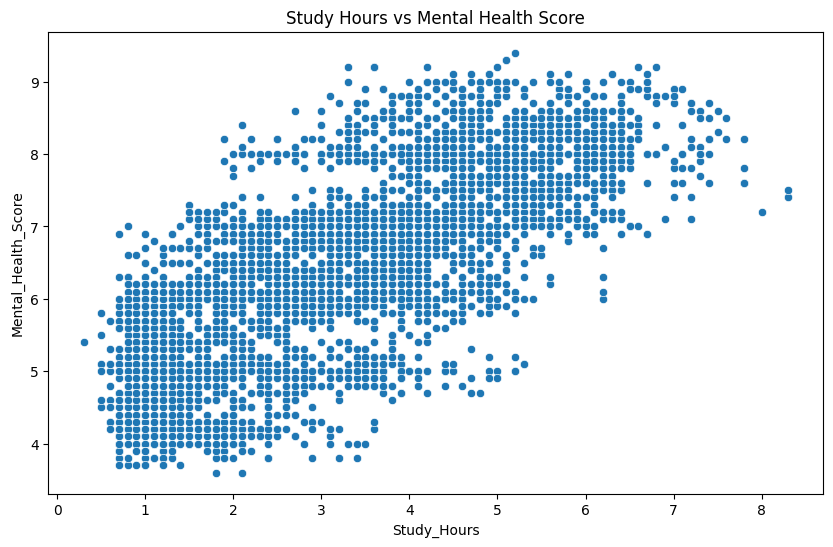

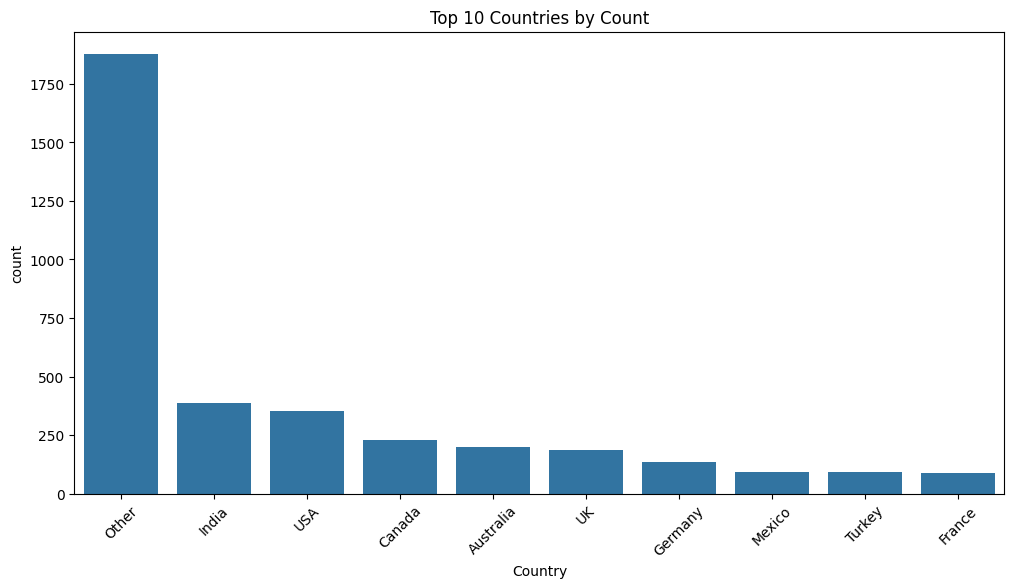

Skewed: ['Study_Hours']
Numeric: ['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night']
Ordinal: ['Stress_Level']
Categorical: ['Gender', 'Academic_Level', 'Most_Used_Platform', 'grouped_country', 'Purpose_Of_Use']
Mean Squared Error: 0.45701905273488
Root Mean Squared Error: 0.6760318429888343
Mean Absolute Error: 0.5361775634720183
R-squared: 0.739794461743302
Training Score: 0.7236771199387538
Testing Score: 0.739794461743302
Random Forest Model Evaluation:
Mean Squared Error: 0.21470133394666663
Root Mean Squared Error: 0.4633587529621801
Mean Absolute Error: 0.3475376000000001
R-squared: 0.8777589778156755
Training Score: 0.9808086115303827
Testing Score: 0.8777589778156755
r2 Score: 0.8782573230757105
mae: 0.3465172085338636
Linear Regression RMSE: 0.6760318429888343
Random Forest RMSE: 0.4633587529621801
                 Model      RMSE       MAE  R-squared  Training Score
0    Linear Regression  0.676032  0.536178   0.739794       

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("mental.csv")
print(df.head())
df.info()
df.describe()
df.shape


# checking a missing values,duplicates and null values
print(df.isnull().sum())

# duplicates check
df.duplicated().sum()
df.drop_duplicates(inplace=True)


# data visualization 
plt.Figure(figsize=(10,6))
sns.histplot(df['Mental_Health_Score'], kde=True)
plt.show()


plt.Figure(figsize=(10,6))
plt.title("heatmap")
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()


df["Stress_Level"].unique()
df.columns
# boxplot for stress level and mental health score
order = ['Low', 'Medium', 'High', 'Very High']
sns.boxplot(x='Stress_Level', y='Mental_Health_Score', data=df, order=order)
plt.show()


plt.figure(figsize=(10, 6))
plt.title("scatter plot for comparision")
sns.scatterplot(x='Avg_Daily_Usage_Hours',y='Mental_Health_Score',data=df)
# sleep hours ke liye
plt.show()



plt.figure(figsize=(10, 6))
plt.title('Sleep Hours vs Mental Health Score')
sns.scatterplot(x='Sleep_Hours_Per_Night', y='Mental_Health_Score', data=df,)
plt.show()

# study hours ke liye
plt.figure(figsize=(10, 6))
plt.title('Study Hours vs Mental Health Score')
sns.scatterplot(x='Study_Hours', y='Mental_Health_Score', data=df,)
plt.show()


# study hours ke liye

# ye physical activity hours ke liye
# sns.scatterplot(x='Physical_Activity_Hours', y='Mental_Health_Score', data=df,)   physical activity hours ke liye
# plt.show()

# ye most used platform ke liye
# sns.scatterplot(x='Most_Used_Platform', y='Mental_Health_Score', data=df,)# Most_Used_Platform ke liye
# plt.show()



platform_counts = df['Most_Used_Platform'].value_counts()
platform_counts


# checking a outliers in the data using boxplot
num_features = df.select_dtypes(include=[np.number])
num_features 

Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)

IQR = Q3 - Q1

LOWER_BOUND = Q1 - 1.5 * IQR
UPPER_BOUND = Q3 + 1.5 * IQR

outliers = ((num_features < LOWER_BOUND) | (num_features > UPPER_BOUND)).sum()
outliers

# converting negative values or unrealistic values to realistic value
df.describe()
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)
df.describe()

# this is a data cleaning and visualization code for a mental health dataset. It includes importing necessary libraries, loading the dataset, checking for missing values and duplicates, visualizing data distributions and relationships, and handling outliers. The code also includes specific visualizations for stress levels, average daily usage hours, sleep hours per night, and the most used platform.
df.shape



num_cols = df.select_dtypes(include=[np.number])
num_cols.skew()
# if skew() is 0 ke pass he to value  to data centralizes he 
# ifs skew() is greater than 0 to value  to data right skewed he
# if skew() is less than 0 to value  to data left skewed he

# top 10 countries ke liye group karna
top_countries = df['Country'].value_counts().index[:10].tolist()
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Country', order=top_countries)
plt.xticks(rotation=45)
plt.title('Top 10 Countries by Count')
plt.show()


def group_countries(country):
    if country in top_countries:
        return country
    else:
        return 'Other'
    
# make sure top_countries exists before applying the function
top_countries = df['Country'].value_counts().index[:10].tolist()

df['grouped_country'] = df['Country'].apply(group_countries)

# list of features for preprocessing

from sklearn.model_selection import train_test_split
# Feature columns

skewed_col = ['Study_Hours']

other_numeric_cols = [
    'Age',
    'Avg_Daily_Usage_Hours',
    'Daily_Unlocks',
    'Physical_Activity_Hours',
    'Sleep_Hours_Per_Night'
]

ordinal_col = ['Stress_Level']

# All features
normal_col = [
    'Gender',
    'Academic_Level',
    'Most_Used_Platform',
    'grouped_country',
    'Purpose_Of_Use'
]

features_cols = (
    skewed_col
    + other_numeric_cols
    + ordinal_col
    + normal_col
)

# train-test split
X = [features_cols]

y = df['Mental_Health_Score']

print("Skewed:", skewed_col)
print("Numeric:", other_numeric_cols)
print("Ordinal:", ordinal_col)
print("Categorical:", normal_col)


X = df[features_cols]
y = df['Mental_Health_Score']
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.30, random_state=42)

# sklearn preprocessing pipelines for different types of features
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np

# pipelines for different types of features
# 1. Skewed features
skew_pipeline = Pipeline(steps=[
    ('log_transformer', FunctionTransformer(np.log1p, validate=False)),
    ('scaler', StandardScaler())
])

# 2. Other numeric features
other_numeric_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# 3. Ordinal feature
ordinal_pipeline = Pipeline(steps=[
    ('encode', OrdinalEncoder(
        categories=[['Low', 'Medium', 'High', 'Very High']]
    ))
])

# 4. Normal categorical features
normal_pipeline = Pipeline(steps=[
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

# Column Transformer
preprocessor = ColumnTransformer(transformers=[
    ('skewed_pipeline', skew_pipeline, skewed_col),
    ('plain_numeric', other_numeric_pipeline, other_numeric_cols),
    ('Ordinal', ordinal_pipeline, ordinal_col),
    ('Normal', normal_pipeline, normal_col)
])


# linear regression model pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.pipeline import Pipeline

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(train_X, train_y)
lr_preds = lr_pipeline.predict(test_X)

# model evaluation
mse = mean_squared_error(test_y, lr_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_y, lr_preds)
r2 = r2_score(test_y, lr_preds)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")

lr_training_score = lr_pipeline.score(train_X, train_y)
lr_testing_score = lr_pipeline.score(test_X, test_y)

print(f"Training Score: {lr_training_score}")
print(f"Testing Score: {lr_testing_score}")
  
  
#   
# random forest regression model pipeline
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random_forest', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_pipeline.fit(train_X, train_y)
rf_preds = rf_pipeline.predict(test_X)

# random forest model evaluation
print("Random Forest Model Evaluation:")

mse_rf = mean_squared_error(test_y, rf_preds)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(test_y, rf_preds)
r2_rf = r2_score(test_y, rf_preds)

# printing the evaluation metrics for the random forest model
print(f"Mean Squared Error: {mse_rf}")
print(f"Root Mean Squared Error: {rmse_rf}")
print(f"Mean Absolute Error: {mae_rf}")
print(f"R-squared: {r2_rf}")

# training and testing scores for random forest model
rf_training_score = rf_pipeline.score(train_X, train_y)
rf_testing_score = rf_pipeline.score(test_X, test_y)

print(f"Training Score: {rf_training_score}")
print(f"Testing Score: {rf_testing_score}")


# ab prameter tuning ke liye grid search ka use karenge

from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 10, 20, 30],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4]
}

param_grid = {
    'random_forest__n_estimators': [100, 200, 300],
    'random_forest__max_depth': [None, 10, 20, 30],
    'random_forest__min_samples_split': [2, 5, 10],
    'random_forest__min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=15,
    scoring='r2',
    n_jobs=-1,
    cv=5,
    random_state=42
)

random_search.fit(train_X, train_y)
rf_best_pipeline = random_search.best_estimator_
rf_best_pipeline

# random search ke liye 
rf_best_params = rf_best_pipeline.predict(test_X)

print(f"r2 Score: {r2_score(test_y, rf_best_params)}")
print(f"mae: {mean_absolute_error(test_y, rf_best_params)}")

# calculate for rmse for linear regression 
lr_rmse = np.sqrt(mean_squared_error(test_y, lr_preds))
print(f"Linear Regression RMSE: {lr_rmse}")


# calculate  rmse for default random forest 
rf_rmse = np.sqrt(mean_squared_error(test_y, rf_preds))
print(f"Random Forest RMSE: {rf_rmse}")

# calculate rmse for tuned random forest
rf_tuned_rmse = np.sqrt(mean_squared_error(test_y, rf_best_params))
rf_tuned_preds = random_search.best_estimator_.predict(test_X)
rf_tuned_training_preds = random_search.best_estimator_.predict(train_X)
rf_tuned_training_score = r2_score(train_y, rf_tuned_training_preds)
rf_tuned_mae = mean_absolute_error(test_y, rf_tuned_preds)
rf_tuned_r2 = r2_score(test_y, rf_tuned_preds)


# create dataframe to consolidate the results
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Tuned Random Forest'],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse],
    'MAE': [mae, mae_rf, rf_tuned_mae], 
    'R-squared': [r2, r2_rf, rf_tuned_r2],
    'Training Score': [lr_training_score, rf_training_score, rf_tuned_training_score] 
})

print(results_df)

# model ko save karna
import joblib
joblib.dump(rf_pipeline, 'mental_health_model.pkl')



# Tuned model save karna zyada behtar rahega
model_payload = {
    'model': rf_best_pipeline,  # Ya rf_pipeline
    'top_countries': top_countries
}

joblib.dump(model_payload, 'mental_health_model.pkl')
print("Model saved successfully!")
